# Personal Finance Analysis
### Anita Roese | March - May 2026

This notebook analyzes personal financial data from March to May of 2026 collected and formatted with Python. The goal of this analysis is to identify spending trends, saving rates, and understand how I manage my money.

## Setup

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

plt.style.use('default')

In [97]:
# Read the CSV file into a DataFrame
df = pd.read_csv('finance_data.csv')


In [98]:
# Convert the 'category' column to lowercase
df['category'] = df['category'].str.lower()

In [99]:
df['date'] = pd.to_datetime(df['date'])

In [100]:
df['month'] = df['date'].dt.month

In [101]:
# Filter the DataFrame to include only expenses
filt = (df['type'] == 'expense')
expenses = df.loc[filt]

In [102]:
# Filter the DataFrame to include only income and calculate the total income
filt = df['type'] == 'income'
income = df.loc[filt]
income['amount'].sum()

np.float64(3004.31)

In [103]:
# Group the expenses by category and calculate the total amount for each category
expenses_grouped = expenses.groupby('category')['amount'].sum().sort_values(ascending=False)

## Section 1 - Spending Analysis

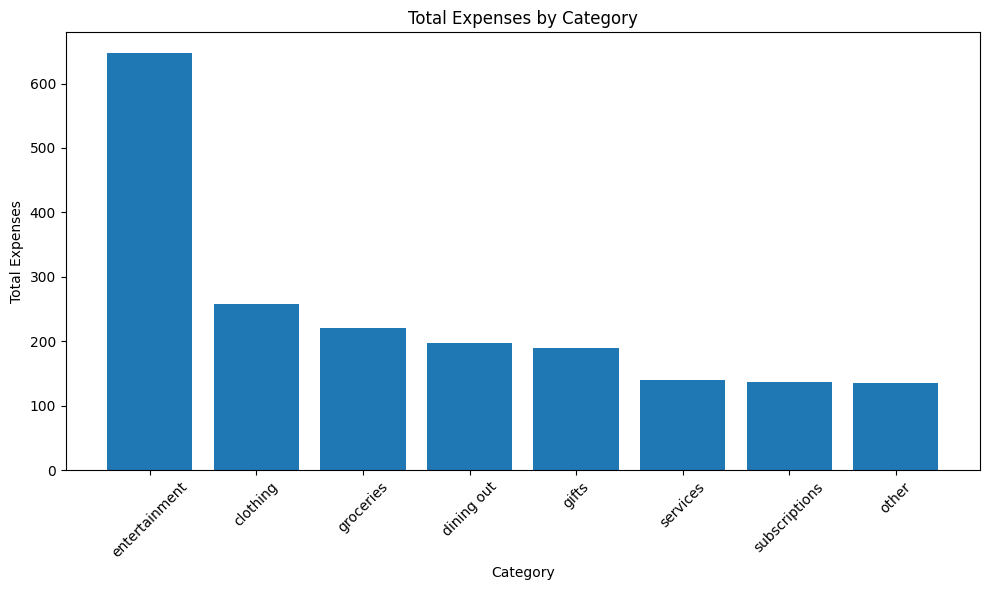

In [104]:
# Create a bar chart to visualize the total expenses by category
plt.figure(figsize=(10, 6))
plt.bar(expenses_grouped.index, expenses_grouped.values)
plt.xlabel('Category')
plt.ylabel('Total Expenses')
plt.title('Total Expenses by Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Spending by Category
The categories were divided into 2 groups: needs and wants. Groceries, services and subscriptions are part of the needs group, while entertainment, clothing, dining out, gifts, and other, are part of the wants group. I have a significant amount of expense with entertainment ($647.16) when comparing to other categories. However, this amount is made of two trips I made, which is not something I do often. Thus, even though the period March - May 2026 indicates an unbalanced expense distribution, it cannot be taken as a usual scenario in my financial life.

In [105]:
# Calculate sum of expenses for needs and wants categories
needs_sum = expenses_grouped[['groceries', 'services', 'subscriptions']].sum()
wants_sum = expenses_grouped[['entertainment', 'clothing', 'dining out', 'gifts', 'other']].sum()

In [106]:
# Calculate the percentage of needs and wants relative to total income
percentage_needs = (needs_sum / income['amount'].sum()) * 100
percentage_wants = (wants_sum / income['amount'].sum()) * 100
print(f"Needs: {percentage_needs:.1f}%")
print(f"Wants: {percentage_wants:.1f}%")

Needs: 16.6%
Wants: 47.5%


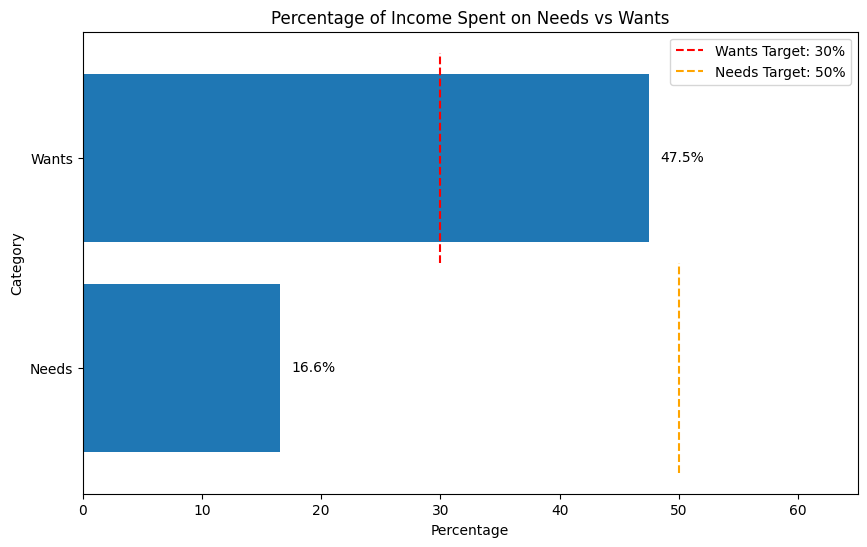

In [107]:
# Create a bar chart to visualize the percentage of income spent on needs vs wants
plt.figure(figsize=(10, 6))
plt.barh(['Needs', 'Wants'], [percentage_needs, percentage_wants])
plt.xlabel('Percentage')
plt.ylabel('Category')
plt.text(percentage_needs + 1, 0, f"{percentage_needs:.1f}%", va='center')
plt.text(percentage_wants + 1, 1, f"{percentage_wants:.1f}%", va='center')
plt.xlim(0, 65)
plt.plot([30, 30], [0.5, 1.5], color='red', linestyle='--', label='Wants Target: 30%')
plt.plot([50, 50], [-0.5, 0.5], color='orange', linestyle='--', label='Needs Target: 50%')
plt.title('Percentage of Income Spent on Needs vs Wants')
plt.legend(loc='upper right')
plt.show()

## Needs vs Wants 

The 50/30/20 rule is a personal finance framework that recommends allocating 50% of income to needs, 30% to wants, and 20% to savings.
My wants spending (47.5%) is significantly above the recommended 30%, while needs (16.6%) are well below the target.
However, as a college student with housing, food, and healthcare covered externally, this distribution is expected.
The more meaningful metric is my savings rate of 35.9%, which exceeds the recommended 20% and leaves room for investing.

## Section 2 - Monthly Trends

In [108]:
expenses_monthly = expenses.groupby('month')['amount'].sum()
income_monthly = income.groupby('month')['amount'].sum()

In [109]:
monthly_df = pd.DataFrame({
    'income': income_monthly, 
    'expenses': expenses_monthly,
    'balance': income_monthly - expenses_monthly
}) 
monthly_df

,income,expenses,balance
month,,,
3,1688.22,694.52,993.70
4,783.01,678.82,104.19
5,533.08,550.23,-17.15


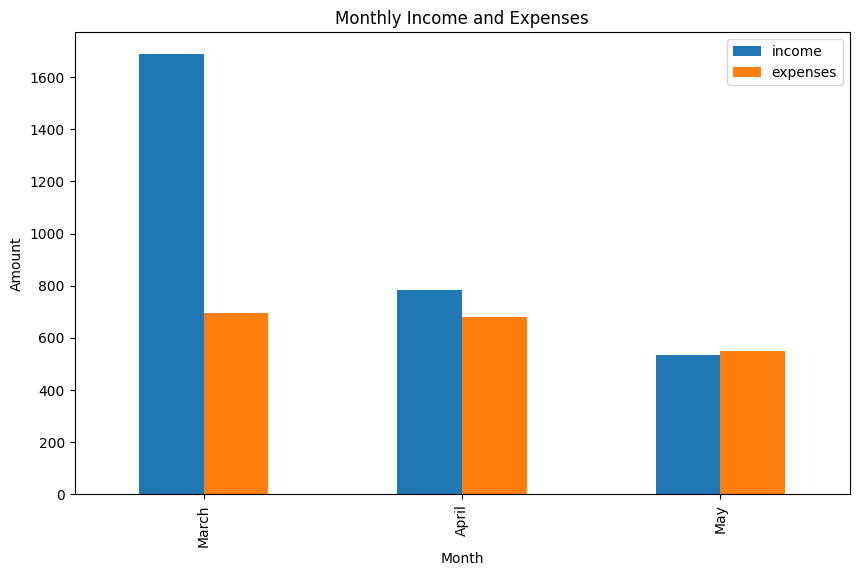

In [110]:
plt.grouped_bar_chart = monthly_df[['income', 'expenses']].plot(kind='bar', figsize=(10, 6))
plt.xlabel('Month')
plt.xticks([0, 1, 2], ['March', 'April', 'May'])
plt.ylabel('Amount')
plt.title('Monthly Income and Expenses')
plt.legend()
plt.show()

### Analysis
March was an atypical month due to the IRS tax refund, which inflated income to $1,688. April was more representative of a typical month — modest income with a small surplus of $104. May showed a slight deficit of $17, as income dropped while expenses remained stable.

A key insight: receiving a large one-time refund can create a false sense of financial security. This is something I need to be mindful of — the refund is a once-a-year event and should be treated as a savings opportunity, not additional spending money.